In [ ]:
import numpy as np
import matplotlib.pyplot as plt

iris = np.genfromtxt('iris_full.csv', dtype=None, delimiter=',', skip_header=1) 
X = iris[:, :4]
y = iris[:, 4] 

intercept = np.ones((X.shape[0], 1))
X = np.concatenate((intercept, X), axis=1)

# shuffle
inds = np.arange(X.shape[0])
np.random.shuffle(inds)

X = X[inds]
y = y[inds]

print(X.shape)
print(y.shape)

(100, 5)
(100,)


In [7]:
X[:20]

array([[1. , 6.6, 2.9, 4.6, 1.3],
       [1. , 6.1, 2.8, 4. , 1.3],
       [1. , 4.7, 3.2, 1.6, 0.2],
       [1. , 6.3, 2.3, 4.4, 1.3],
       [1. , 5.7, 4.4, 1.5, 0.4],
       [1. , 5.5, 2.4, 3.7, 1. ],
       [1. , 5.5, 3.5, 1.3, 0.2],
       [1. , 5.4, 3.9, 1.7, 0.4],
       [1. , 5. , 3.5, 1.3, 0.3],
       [1. , 5.4, 3.4, 1.5, 0.4],
       [1. , 5.8, 4. , 1.2, 0.2],
       [1. , 5.7, 2.8, 4.1, 1.3],
       [1. , 4.8, 3.4, 1.9, 0.2],
       [1. , 6.3, 2.5, 4.9, 1.5],
       [1. , 4.7, 3.2, 1.3, 0.2],
       [1. , 4.4, 3. , 1.3, 0.2],
       [1. , 5.6, 2.7, 4.2, 1.3],
       [1. , 5.2, 2.7, 3.9, 1.4],
       [1. , 4.8, 3.4, 1.6, 0.2],
       [1. , 5.6, 2.9, 3.6, 1.3]])

In [ ]:
def sigmoid_function(z):
    return 1 / (1 + np.exp(-z))

def loss_function(y_hat, y):
    #return (-y*np.log(y_hat) - (1 - y)*np.log(1 - y_hat)).mean()
    return ( -y.T.dot(np.log(y_hat)) - (1 - y).T.dot(np.log(1 - y_hat)) ) / y.size

def predict(X, theta):    
    y_hat = sigmoid_function(np.dot(X, theta))
    return y_hat

def compute_gradient(X, y_hat, y):
    return np.dot(X.T, (y_hat - y)) / y.size

In [ ]:
# training
lr=0.01
num_iter=2000

theta = np.array([0.01, 0.05, 0.01, 0.5, -0.1])
#theta = np.array([10, 0.05, 10, 0.5, -0.1])
losses = []
accs   = []

for i in range(num_iter):
    # predict z
    y_hat = predict(X, theta)
    
    # compute loss
    loss = loss_function(y_hat, y)

    # compute mean of gradient
    gradient = compute_gradient(X, y_hat, y)
    
    # update
    theta -= lr*gradient     
    
    
    
    # ==========for debug
    # loss
    losses.append(loss)

    # accuracy for training
    preds = predict(X, theta).round()
    acc = (preds == y).mean()
    accs.append(acc) 

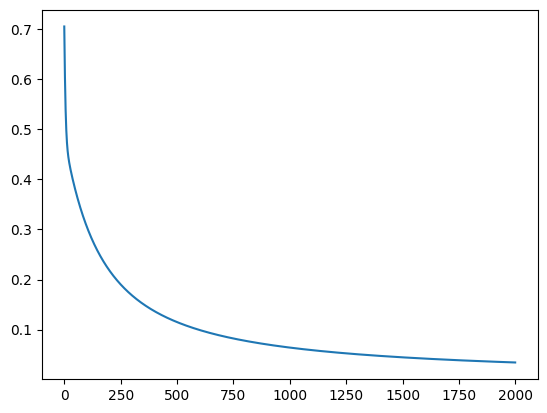

In [27]:
# show figures
plt.plot(losses)
plt.show()

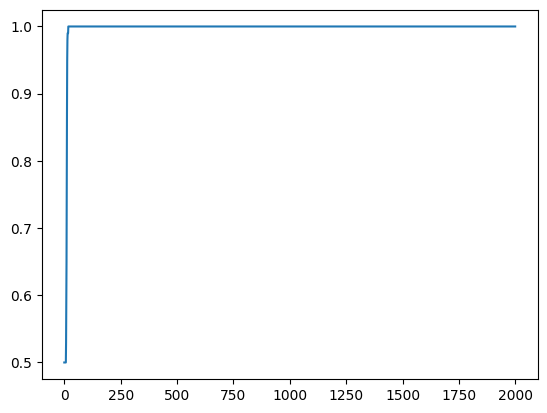

In [28]:
plt.plot(accs)
plt.show()

In [7]:
preds = predict(X, theta).round()
print(preds)
print(y)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]
[0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0.
 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1.
 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.
 1. 1. 1. 0.]
